# Benchmark - [OpenAI's GPT OSS 120B](https://huggingface.co/lmstudio-community/gpt-oss-120b-GGUF)

**Evaluation:** Tasks 01-06, excl. 03

**Hardware:** Apple M5 Max 128GB

In [1]:
import textwrap

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from benchmark_lib import (
  DATA_DIR,
  RUNS_PER_BATCH,
  SERIES,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  plot_timeouts,
  save_runs,
)

HARDWARE = "Apple M5 Max 128GB"
MODEL_LABEL = "GPT OSS 120B"


In [2]:
MODEL_NAME = "gpt-oss-120b"
benchmark_dir = DATA_DIR / "openai" / MODEL_NAME

if (not benchmark_dir.exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir, redact=("openai",))


In [3]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260814_224100,2026-08-14 22:41:00.877451,True,0.8,4,5,False,True,102,...,gpt-oss-120b-MXFP4,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",10381,5252,145371,0,161004
1,01-data-loading,20260814_224243,2026-08-14 22:42:43.097342,True,0.8,4,5,False,True,70,...,gpt-oss-120b-MXFP4,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",7007,3958,92968,0,103933
2,01-data-loading,20260814_224353,2026-08-14 22:43:53.565703,True,0.6,3,5,False,True,81,...,gpt-oss-120b-MXFP4,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",6911,4700,91260,0,102871
3,01-data-loading,20260814_224514,2026-08-14 22:45:14.777440,True,0.8,4,5,False,True,99,...,gpt-oss-120b-MXFP4,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",9952,5341,185648,0,200941
4,01-data-loading,20260814_224654,2026-08-14 22:46:54.655558,True,0.8,4,5,False,True,66,...,gpt-oss-120b-MXFP4,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",5360,3955,62889,0,72204


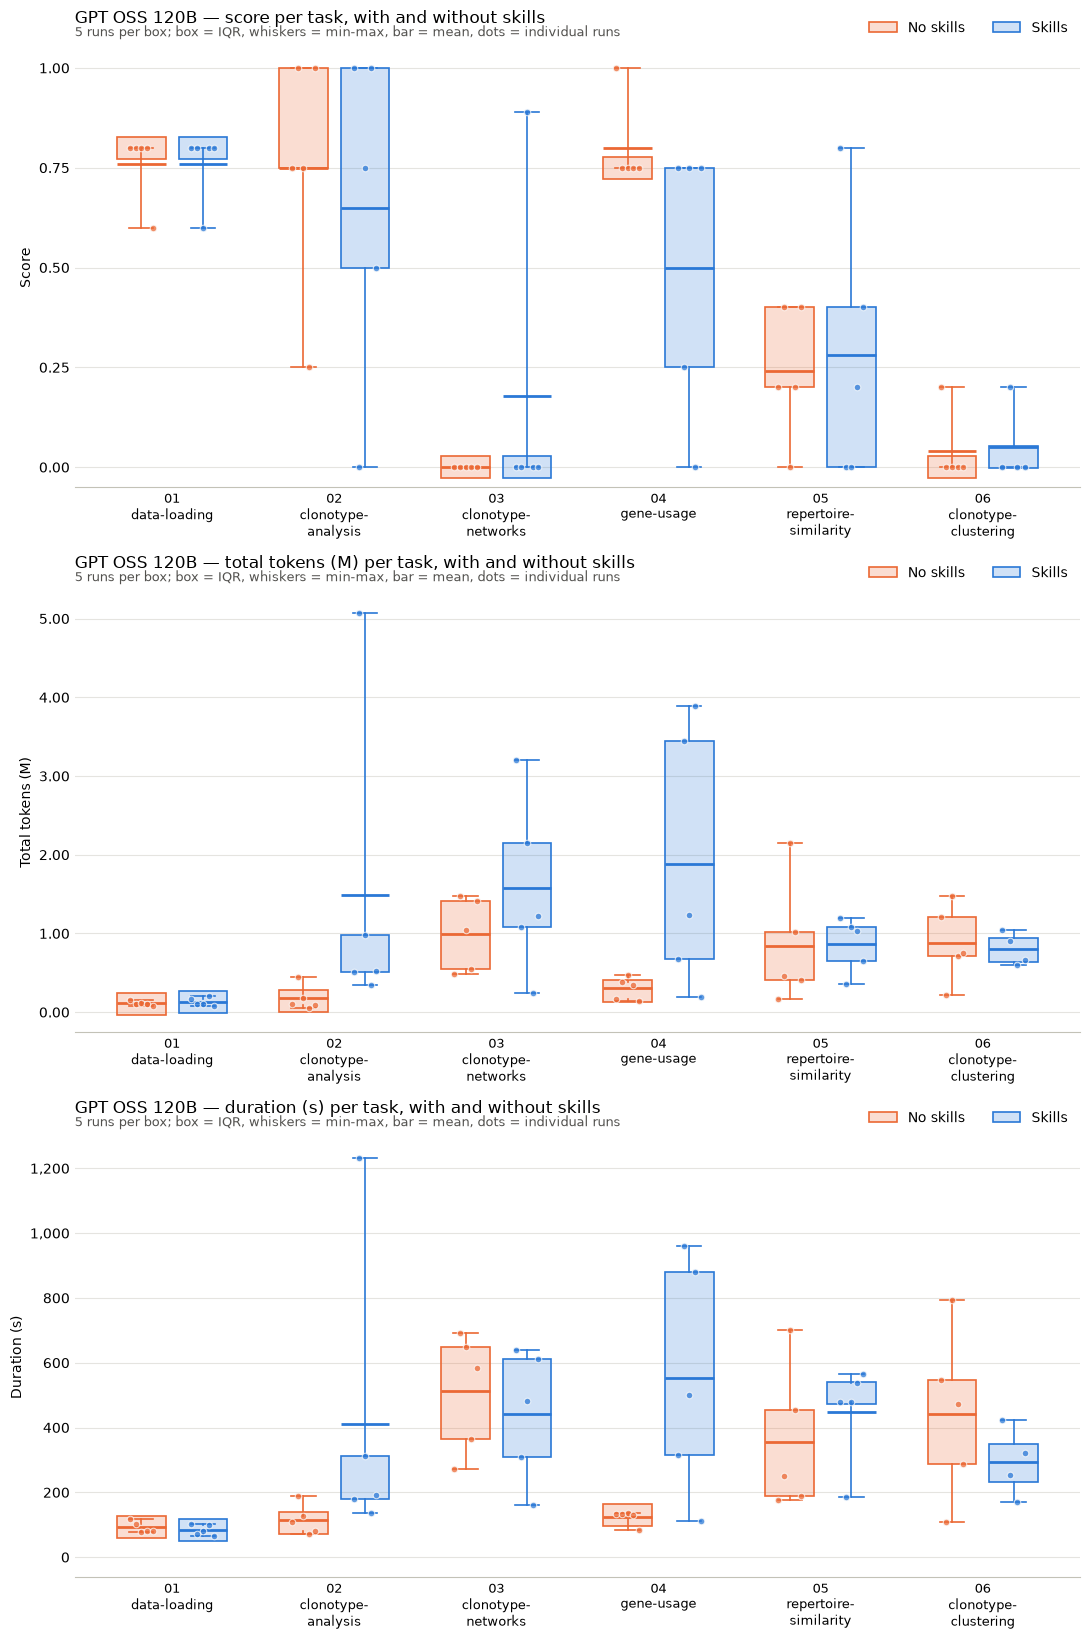

In [4]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


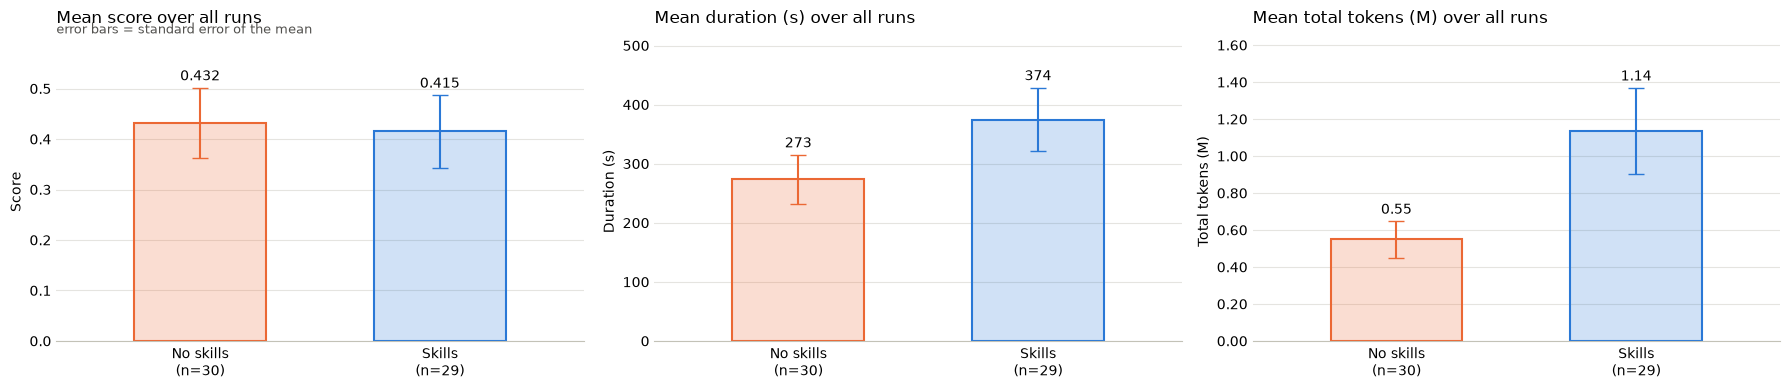

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [6]:
significance = compare_skills(benchmark)


In [7]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,30 vs 29,0.431667,0.415134,-0.016533,0.919263,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,0.760000,0.760000,0.000000,1.000000,1.000000,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.750000,0.650000,-0.100000,0.827147,1.000000,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,0.000000,0.177778,0.177778,0.423711,1.000000,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,0.800000,0.500000,-0.300000,0.123056,0.738339,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.240000,0.280000,0.040000,1.000000,1.000000,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 4,0.040000,0.050000,0.010000,1.000000,1.000000,False
7,all tasks (paired by task),Wilcoxon signed-rank,6 tasks,0.431667,0.402963,-0.028704,1.000000,NaN,False


In [8]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,30 vs 29,273.233333,374.379310,101.145977,0.149728,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,92.200000,83.600000,-8.600000,0.345742,0.504762,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,115.000000,410.400000,295.400000,0.031746,0.190476,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,512.600000,440.600000,-72.000000,0.547619,0.547619,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,123.200000,553.800000,430.600000,0.095238,0.285714,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,354.200000,449.200000,95.000000,0.420635,0.504762,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 4,442.200000,292.250000,-149.950000,0.412698,0.504762,False
7,all tasks (paired by task),Wilcoxon signed-rank,6 tasks,273.233333,371.641667,98.408333,0.562500,NaN,False


In [9]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,30 vs 29,548627.5,1.136384e+06,5.877569e+05,0.028459,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,111134.6,1.281906e+05,1.705600e+04,0.841270,0.841270,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,176096.8,1.486252e+06,1.310155e+06,0.015873,0.095238,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,991556.4,1.580510e+06,5.889538e+05,0.547619,0.821429,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,301354.6,1.888167e+06,1.586813e+06,0.055556,0.166667,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,838482.2,8.655556e+05,2.707340e+04,0.547619,0.821429,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 4,873140.4,8.029430e+05,-7.019740e+04,0.730159,0.841270,False
7,all tasks (paired by task),Wilcoxon signed-rank,6 tasks,548627.5,1.125270e+06,5.766422e+05,0.156250,NaN,False


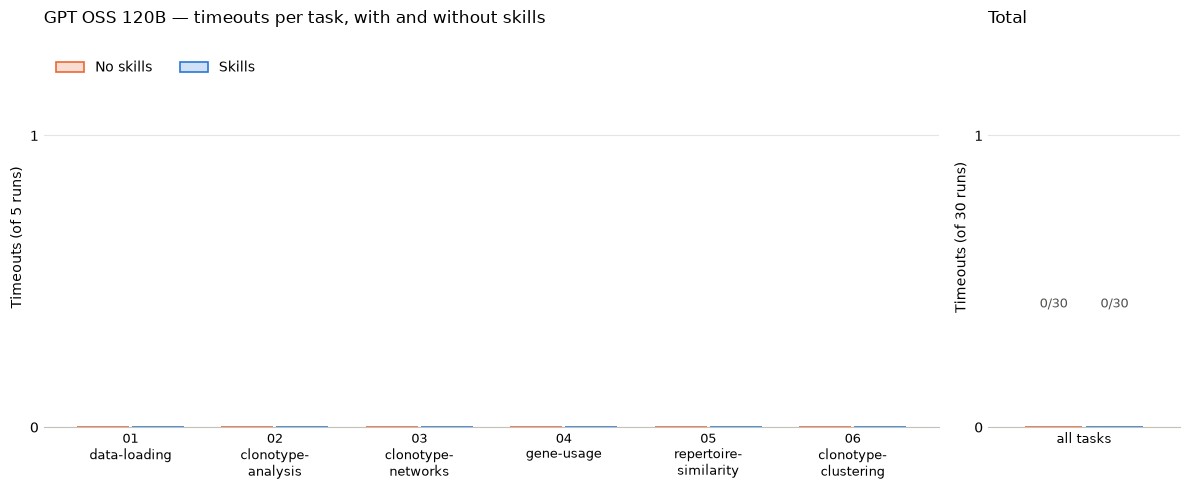

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_timeouts(benchmark, model_label=MODEL_LABEL, axs=axs)
fig.tight_layout()
plt.show()